In [3]:
#Task 1.1 Variable Roles and Data Types
import pandas as pd
import numpy as np

df = pd.read_csv('dataset_ifn580_262_v1.csv')

columns_to_check = [
    'destination',
    'passanger',
    'weather',
    'coupon',
    'expiration',
    'gender',
    'maritalStatus',
    'education',
    'occupation'
]

for col in columns_to_check:
    print(col, ":", df[col].unique())

destination : ['No Urgent Place' 'Home' 'Work']
passanger : ['Alone' 'Friend(s)' 'Kid(s)' 'Partner']
weather : ['Sunny' 'Rainy' 'Snowy']
coupon : ['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']
expiration : ['1d' '2h']
gender : ['Female' 'Male']
maritalStatus : ['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
education : ['Some college - no degree' 'Bachelors degree' 'Associates degree'
 'High School Graduate' 'Graduate degree (Masters or Doctorate)'
 'Some High School']
occupation : ['Unemployed' 'Architecture & Engineering' 'Student'
 'Education&Training&Library' 'Healthcare Support'
 'Healthcare Practitioners & Technical' 'Sales & Related' 'Management'
 'Arts Design Entertainment Sports & Media' 'Computer & Mathematical'
 'Life Physical Social Science' 'Personal Care & Service'
 'Community & Social Services' 'Office & Administrative Support'
 'Construction & Extraction' 'Legal' 'Retired'
 'Installation Maintenance & Repair' 

# Missing Value

- 'car' has approximately 99.15% missing values and may be unreliable for modelling.
- 'temperature' has a small proportion of missing values.
- 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', and 'Restaurant20To50' also have small proportions of missing values.
- The restaurant/visit-frequency variables contain ordered categories, so they should be treated as ordinal rather than nominal.

'Temperture' float64/ 1.970987 [55. 80. nan 30.]

'Bar' object/ 0.843582 

'Coffeehouse' object/ 1.710817

'Carryaway' object/ 1.190476

'RestaurantLessThan20' object/ 1.024913

'Restaurant20To50' object/ 1.490066

# Data exploration

Age:
[21, 46, 26, 31, 41, 50plus, 36, below21]
- object in pandas
- contains numeric categories plus textual boundaries such as below21 / 50plus
- ordered meaning
- likely ordinal

income:
[$37500-$49999, $62500-$74999, $12500-$24999, $75000-$87499, $50000-$62499, $25000-$37499, $100000 or more, $87500-$99999, less than $12500]
- object in pandas
- income range represented as text
- ordered meaning
- likely ordinal

time:
[2PM, 10AM, 6PM, 7AM, 10PM]
- object in pandas
- clock time represented as text with AM/PM
- requires numerical/ordered representation before modelling

In [4]:
# Task 1.2 Data Quality, Cleaning and Preprocessing
missing_count = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percent
})

missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

display(missing_summary)

,Missing Count,Missing Percentage
temperature,250,1.970987
car,12576,99.148534
Bar,107,0.843582
CoffeeHouse,217,1.710817
CarryAway,151,1.190476
RestaurantLessThan20,130,1.024913
Restaurant20To50,189,1.490066


Car:
- missing rate> 99%
- too little observed information
- Impuation would be unreliable
- Remove the variable

In [5]:
print("Mean:", df['temperature'].mean())
print("Median:", df['temperature'].median())

Mean: 63.28976998552356
Median: 80.0


Temperature:
- has 250 missing values, which is a relatively small proportion of the dataset.
- The mean is 63.289, while the median is 80.
- The original temperature values are 30, 55, and 80.
- Median imputation is selected because it keeps the imputed value within the existing temperature values and avoids introducing a new value that does not appear in the original dataset.

In [6]:
for col in ['Bar']:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

Bar
Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
NaN       107
Name: count, dtype: int64



Bar:
- has 107 missing values, which is a small proportion of the dataset.
- The variable contains ordered frequency categories such as never, less1, 1~3, 4~8, and gt8.
- The most frequent category is never
- Mode imputation is selected because the variable is categorical and the missing proportion is low.

In [7]:
for col in ['CoffeeHouse']:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

CoffeeHouse
CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
NaN       217
Name: count, dtype: int64



CoffeeHouse:
- has 217 missing values, which is a small proportion of the dataset.
- The variable contains ordered frequency categories such as never, less1, 1~3, 4~8, and gt8.
- The most frequent category is less1
- Mode imputation is selected because the variable is categorical and the missing proportion is low.

In [8]:
for col in ['CarryAway']:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

CarryAway
CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
NaN       151
Name: count, dtype: int64



CarryAway:
- has 151 missing values, which is a small proportion of the dataset.
- The variable contains ordered frequency categories such as never, less1, 1~3, 4~8, and gt8.
- The most frequent category is 1~3.
- Mode imputation is selected because the variable is categorical and the missing proportion is low.

In [9]:
for col in ['RestaurantLessThan20']:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

RestaurantLessThan20
RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     220
NaN       130
Name: count, dtype: int64



RestaurantLessThan20:
- has 130 missing values, which is a small proportion of the dataset.
- The variable contains ordered frequency categories such as never, less1, 1~3, 4~8, and gt8.
- The most frequent category is 1~3.
- Mode imputation is selected because the variable is categorical and the missing proportion is low.

In [10]:
for col in ['Restaurant20To50']:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

Restaurant20To50
Restaurant20To50
less1    6077
1~3      3290
never    2136
4~8       728
gt8       264
NaN       189
Name: count, dtype: int64



Restaurant20To50:
- has 189 missing values, which is a small proportion of the dataset.
- The variable contains ordered frequency categories such as never, less1, 1~3, 4~8, and gt8.
- The most frequent category is less1.
- Mode imputation is selected because the variable is categorical and the missing proportion is low.

In [11]:
# Task 1.3 Mixed Numerical/Textual Representation and Time

df = df.drop(columns=['car'])
df['temperature'] = df['temperature'].fillna(df['temperature'].median())
df['Bar'] = df['Bar'].fillna(df['Bar'].mode()[0])
df['CoffeeHouse'] = df['CoffeeHouse'].fillna(df['CoffeeHouse'].mode()[0])
df['CarryAway'] = df['CarryAway'].fillna(df['CarryAway'].mode()[0])
df['RestaurantLessThan20'] = df['RestaurantLessThan20'].fillna(df['RestaurantLessThan20'].mode()[0])
df['Restaurant20To50'] = df['Restaurant20To50'].fillna(df['Restaurant20To50'].mode()[0])

df.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
is_accepted             0
dtype: int64

In [12]:
# encoding(maping)
age_mapping = {
    'below21': 0,
    '21':1,
    '26':2,
    '31':3,
    '36':4,
    '41':5,
    '46':6,
    '50plus': 7
}
df['age'] = df['age'].map(age_mapping)

In [13]:
df['age'].unique()

array([1, 6, 2, 3, 5, 7, 4, 0], dtype=int64)

In [14]:
df['age'].isnull().sum()

0

In [15]:
time_mapping = {
    '7AM': 0,
    '10AM': 1,
    '2PM': 2,
    '6PM': 3,
    '10PM': 4
}
df['time'] = df['time'].map(time_mapping)

### Time Encoding

- The `time` variable has a natural chronological order during the day.
- The categories were manually ordered from the earliest to the latest time.
- Consecutive integers were used to preserve this order in a numerical form.
- These encoded values represent ordinal positions only and do not represent the actual time intervals between categories.

In [16]:
df['time'].unique()

array([2, 1, 3, 0, 4], dtype=int64)

In [17]:
df['time'].isnull().sum()

0

In [18]:
income_mapping = {
    'Less than $12500': 0,
    '$12500 - $24999': 1,
    '$25000 - $37499': 2,
    '$37500 - $49999': 3,
    '$50000 - $62499': 4,
    '$62500 - $74999': 5,
    '$75000 - $87499': 6,
    '$87500 - $99999': 7,
    '$100000 or More': 8
}
df['income'] = df['income'].map(income_mapping)

In [19]:
df['income'].unique()

array([3, 5, 1, 6, 4, 2, 8, 7, 0], dtype=int64)

In [20]:
df['income'].isnull().sum()

0

In [21]:
df['education'].unique()

array(['Some college - no degree', 'Bachelors degree',
       'Associates degree', 'High School Graduate',
       'Graduate degree (Masters or Doctorate)', 'Some High School'],
      dtype=object)

In [22]:
education_mapping = {
    'Some High School': 0,
    'High School Graduate': 1,
    'Some college - no degree': 2,
    'Associates degree': 3,
    'Bachelors degree': 4,
    'Graduate degree (Masters or Doctorate)': 5
}
df['education'] = df['education'].map(education_mapping)

In [23]:
df['education'].unique()

array([2, 4, 3, 1, 5, 0], dtype=int64)

In [24]:
df['education'].isnull().sum()

0

In [25]:
frequency_mapping = {
    'never': 0,
    'less1': 1,
    '1~3': 2,
    '4~8': 3,
    'gt8': 4
}
frequency_columns = [
    'Bar',
    'CoffeeHouse',
    'CarryAway',
    'RestaurantLessThan20',
    'Restaurant20To50'
]

for col in frequency_columns:
    df[col] = df[col].map(frequency_mapping)

In [26]:
df[frequency_columns].isnull().sum()

Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
dtype: int64

In [27]:
for col in frequency_columns:
    print(col, df[col].unique())

Bar [0 1 2 4 3]
CoffeeHouse [0 1 3 2 4]
CarryAway [2 3 4 1 0]
RestaurantLessThan20 [3 2 1 4 0]
Restaurant20To50 [2 1 0 4 3]


In [28]:
expiration_mapping = {
    '2h': 0,
    '1d': 1
}
df['expiration'] = df['expiration'].map(expiration_mapping)

In [29]:
df['expiration'].unique()

array([1, 0], dtype=int64)

In [30]:
df['expiration'].isnull().sum()

0

In [31]:
gender_mapping = {
    'Female': 0,
    'Male': 1
}
df['gender'] = df['gender'].map(gender_mapping)

In [32]:
df['gender'].unique()

array([0, 1], dtype=int64)

In [33]:
destination_encoded = pd.get_dummies(
    df['destination'],
    prefix='destination',
    dtype=int
)

### Nominal Variable Encoding

- `destination` is a nominal categorical variable with no natural order.
- One-hot encoding is used to convert the categories into numerical binary variables.
- Each category is represented by a separate 0/1 column.

In [34]:
destination_encoded.head()

,destination_Home,destination_No Urgent Place,destination_Work
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


In [35]:
df = pd.concat([df, destination_encoded], axis=1)

In [36]:
df = df.drop(columns=['destination'])

In [37]:
df.head()

,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,...,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,is_accepted,destination_Home,destination_No Urgent Place,destination_Work
0,Alone,Sunny,55.0,2,Restaurant(<20),1,0,1,Unmarried partner,1,...,2,1,0,0,0,1,1,0,1,0
1,Friend(s),Sunny,80.0,1,Coffee House,0,0,1,Unmarried partner,1,...,2,1,0,0,0,1,0,0,1,0
2,Friend(s),Sunny,80.0,1,Carry out & Take away,0,0,1,Unmarried partner,1,...,2,1,1,0,0,1,1,0,1,0
3,Friend(s),Sunny,80.0,2,Coffee House,0,0,1,Unmarried partner,1,...,2,1,1,0,0,1,0,0,1,0
4,Friend(s),Sunny,80.0,2,Coffee House,1,0,1,Unmarried partner,1,...,2,1,1,0,0,1,0,0,1,0


In [38]:
nominal_columns = [
    'passanger',
    'weather',
    'coupon',
    'maritalStatus',
    'occupation'
]
nominal_encoded = pd.get_dummies(
    df[nominal_columns],
    prefix=nominal_columns,
    dtype=int
)
df = pd.concat([df, nominal_encoded], axis=1)

In [39]:
df = df.drop(columns=nominal_columns)

In [40]:
df.head()

,temperature,time,expiration,gender,age,has_children,education,income,Bar,CoffeeHouse,...,occupation_Management,occupation_Office & Administrative Support,occupation_Personal Care & Service,occupation_Production Occupations,occupation_Protective Service,occupation_Retired,occupation_Sales & Related,occupation_Student,occupation_Transportation & Material Moving,occupation_Unemployed
0,55.0,2,1,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1
1,80.0,1,0,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1
2,80.0,1,0,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1
3,80.0,2,0,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1
4,80.0,2,1,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1


In [41]:
df.dtypes

temperature                                    float64
time                                             int64
expiration                                       int64
gender                                           int64
age                                              int64
                                                ...   
occupation_Retired                               int32
occupation_Sales & Related                       int32
occupation_Student                               int32
occupation_Transportation & Material Moving      int32
occupation_Unemployed                            int32
Length: 64, dtype: object

# checking Object

- 'df.select_dtypes(include='object').columns' was used to check whether any text-based columns remained after encoding.
- No 'object' columns remain.
- `df.isnull().sum().sum()` was used to check the total number of missing values in the processed dataset.
- The result was 0, confirming that no missing values remain.

In [42]:
# Task 1.4 – Correlation Analysis and Redundant Variables

df.select_dtypes(exclude='number').columns

Index([], dtype='object')

In [43]:
df.dtypes[df.dtypes == 'object']

Series([], dtype: object)

In [44]:
correlation_matrix = df.corr()

In [45]:
correlation_matrix

,temperature,time,expiration,gender,age,has_children,education,income,Bar,CoffeeHouse,...,occupation_Management,occupation_Office & Administrative Support,occupation_Personal Care & Service,occupation_Production Occupations,occupation_Protective Service,occupation_Retired,occupation_Sales & Related,occupation_Student,occupation_Transportation & Material Moving,occupation_Unemployed
temperature,1.000000,-0.035530,-0.121833,-0.025419,-0.017893,-0.019894,0.008683,-0.029969,-0.005448,-0.016049,...,0.040296,-0.019941,-0.003830,-0.001028,0.022685,0.021477,-0.003243,0.022421,0.002254,-0.029577
time,-0.035530,1.000000,-0.030381,-0.003593,0.005114,0.026883,0.009751,0.010860,-0.014447,-0.000058,...,-0.020176,0.001148,0.003669,0.007005,-0.010955,-0.013038,0.000643,-0.008162,0.000166,0.019036
expiration,-0.121833,-0.030381,1.000000,0.001264,-0.021208,-0.016020,-0.016356,-0.020606,-0.009821,-0.002195,...,-0.014373,0.025240,-0.003858,0.017989,-0.007942,-0.007158,-0.002287,0.016554,0.000155,0.008767
gender,-0.025419,-0.003593,0.001264,1.000000,-0.099847,-0.159956,-0.004301,0.101738,0.161595,-0.044470,...,0.088371,-0.097346,-0.027272,0.058632,0.033578,0.013924,0.057932,0.092138,0.055712,-0.137959
age,-0.017893,0.005114,-0.021208,-0.099847,1.000000,0.442096,0.158249,0.084885,-0.158573,-0.049766,...,0.060981,0.025226,0.110139,0.067808,0.021135,0.313798,-0.000859,-0.396503,0.075858,-0.082651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
occupation_Retired,0.021477,-0.013038,-0.007158,0.013924,0.313798,0.114056,0.051814,-0.002094,-0.132851,-0.085394,...,-0.053599,-0.046416,-0.023836,-0.018849,-0.023836,1.000000,-0.061883,-0.076126,-0.026649,-0.083800
occupation_Sales & Related,-0.003243,0.000643,-0.002287,0.057932,-0.000859,-0.046576,-0.032885,-0.063590,-0.009931,-0.050215,...,-0.081674,-0.070729,-0.036321,-0.028722,-0.036321,-0.061883,1.000000,-0.116002,-0.040608,-0.127696
occupation_Student,0.022421,-0.008162,0.016554,0.092138,-0.396503,-0.222232,-0.145635,-0.117955,-0.021115,0.125814,...,-0.100474,-0.087009,-0.044681,-0.035333,-0.044681,-0.076126,-0.116002,1.000000,-0.049955,-0.157088
occupation_Transportation & Material Moving,0.002254,0.000166,0.000155,0.055712,0.075858,0.048911,-0.066045,-0.002199,0.009791,-0.007444,...,-0.035172,-0.030459,-0.015641,-0.012369,-0.015641,-0.026649,-0.040608,-0.049955,1.000000,-0.054991


In [46]:
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        corr_value = correlation_matrix.iloc[i, j]

        if abs(corr_value) > 0.90:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                corr_value
            ))

high_corr_pairs

[('direction_opp', 'direction_same', -1.0)]

# remove direction_opp

- direction_same and direction_opp are perfectly negatively correlated (r = -1.0).
- Both variables contain redundant information.
- direction_same is retained because it is more directly interpretable.
- direction_opp is removed.

In [47]:
df = df.drop(columns=['direction_opp'])

In [48]:
correlation_matrix = df.corr()

In [49]:
'direction_opp' in df.columns

False

# Task 5

In [50]:
X = df.drop("is_accepted", axis=1)
y = df["is_accepted"]

from sklearn.model_selection import train_test_split

X_train_ind, X_test_ind, y_train_ind, y_test_ind = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Checking status

Confirm that the redundant 'direction_opp' variable has been removed before starting the individual evaluation.

In [51]:
print("direction_opp" in X.columns)

False


# Individual train-test split

A 70:30 train-test split is used for my individual evaluation. A fixed random state is used so that the split can be reproduced.

In [53]:
print(X_train_ind.shape)
print(X_test_ind.shape)
print(y_train_ind.shape)
print(y_test_ind.shape)

(8878, 62)
(3806, 62)
(8878,)
(3806,)


# Best Decision Tree evaluation
The tuned Decision Tree from Task 2 is evaluated using my individual 70:30 train-test split.

In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

dt_ind = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=20,
    random_state=42
)

dt_ind.fit(X_train_ind, y_train_ind)

dt_train_pred = dt_ind.predict(X_train_ind)
dt_test_pred = dt_ind.predict(X_test_ind)
dt_test_prob = dt_ind.predict_proba(X_test_ind)[:, 1]

dt_train_accuracy = accuracy_score(y_train_ind, dt_train_pred)
dt_test_accuracy = accuracy_score(y_test_ind, dt_test_pred)
dt_auc = roc_auc_score(y_test_ind, dt_test_prob)

print("Decision Tree Training Accuracy:", round(dt_train_accuracy, 4))
print("Decision Tree Testing Accuracy:", round(dt_test_accuracy, 4))
print("Decision Tree AUC:", round(dt_auc, 4))

Decision Tree Training Accuracy: 0.7702
Decision Tree Testing Accuracy: 0.6981
Decision Tree AUC: 0.7438


This Decision Tree evaluation uses the same 70:30 split, random state, processed dataset and tuned parameters as Task 2. Therefore, the resulting training accuracy, testing accuracy and AUC are the same as previously reported. This step is repeated here to confirm the model performance before comparing it with the other best-performing models in Task 5.

# Best Logistic Regression evaluation
The tuned Logistic Regression selected in Task 3 is evaluated on my individual 70:30 split using the same regression-specific preprocessing and best hyperparameter settings.

# Checking the LR dataset

In [55]:
df_lr_base = df.copy()

df_lr = pd.get_dummies(df_lr_base, drop_first=True, dtype=int)

y_lr = df_lr['is_accepted']
X_lr = df_lr.drop(columns=['is_accepted'])

print("direction_opp present:", 'direction_opp' in X_lr.columns)
print("is_accepted in features:", 'is_accepted' in X_lr.columns)
print("Total samples:", X_lr.shape[0])
print("Total features:", X_lr.shape[1])

direction_opp present: False
is_accepted in features: False
Total samples: 12684
Total features: 62


The checks look correct: the redundant variable and target are both excluded from X, and all 12,684 samples are still present.

# 70:30 split check
For Task 5, I used the same 70:30 train-test split and random_state=42 across all three models, so they’re all evaluated on the exact same test dataset. I also checked the class ratios to make sure the acceptance distribution stays similar between the training and test sets.

In [67]:
from sklearn.model_selection import train_test_split

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr,
    y_lr,
    test_size=0.3,
    random_state=42
)

In [68]:
print("Train set shape:", X_train_lr.shape)
print("Test set shape:", X_test_lr.shape)
print("\nTrain class distribution:")
print(y_train_lr.value_counts(normalize=True).round(4))
print("\nTest class distribution:")
print(y_test_lr.value_counts(normalize=True).round(4))

Train set shape: (8878, 62)
Test set shape: (3806, 62)

Train class distribution:
is_accepted
1    0.5692
0    0.4308
Name: proportion, dtype: float64

Test class distribution:
is_accepted
1    0.5667
0    0.4333
Name: proportion, dtype: float64


# Scaling check
Task 3 scaled the Logistic Regression inputs before fitting the model. I fitted the scaler on the training set and then used the same scaler on the test set.

In [69]:
from sklearn.preprocessing import StandardScaler

scaler_lr = StandardScaler()
X_train_lr_scaled = scaler_lr.fit_transform(X_train_lr)
X_test_lr_scaled = scaler_lr.transform(X_test_lr)

In [70]:
train_overall_mean = X_train_lr_scaled.mean(axis=0).mean()
train_overall_std = X_train_lr_scaled.std(axis=0).mean()
print(f"Overall mean of scaled train features: {train_overall_mean:.4f}")
print(f"Overall std of scaled train features: {train_overall_std:.4f}")

Overall mean of scaled train features: -0.0000
Overall std of scaled train features: 0.9839


The overall mean is basically 0 and the average standard deviation is close to 1, so the scaling looks reasonable.

# Reproducing the best LR model
Task 3 selected the GridSearchCV model with 'C=1' as the best Logistic Regression model. I’m using the same setting here on my Task 5 split rather than tuning it again.

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

lr_ind = LogisticRegression(
    C=1,
    penalty='l2',
    solver='lbfgs',
    random_state=42,
    max_iter=1000
)

lr_ind.fit(X_train_lr_scaled, y_train_lr)

lr_train_pred = lr_ind.predict(X_train_lr_scaled)
lr_test_pred = lr_ind.predict(X_test_lr_scaled)
lr_test_prob = lr_ind.predict_proba(X_test_lr_scaled)[:, 1]

lr_train_acc = accuracy_score(y_train_lr, lr_train_pred)
lr_test_acc = accuracy_score(y_test_lr, lr_test_pred)
lr_auc = roc_auc_score(y_test_lr, lr_test_prob)

print("Logistic Regression Training Accuracy:", round(lr_train_acc, 4))
print("Logistic Regression Testing Accuracy:", round(lr_test_acc, 4))
print("Logistic Regression AUC:", round(lr_auc, 4))

Logistic Regression Training Accuracy: 0.6869
Logistic Regression Testing Accuracy: 0.6797
Logistic Regression AUC: 0.7292


###### The reproduced LR gives 0.6869 training accuracy, 0.6797 test accuracy and 0.7292 AUC. The small gap between train and test accuracy does not show obvious overfitting on this split.

# Best Neural Network evaluation
Task 4 selected the full tuned Neural Network as the better NN model, so I’m reproducing that model here using my 70:30 split.

# NN data check
Before rebuilding the NN, I checked the input again because Task 4 uses the full processed feature set rather than the regression-specific version from Task 3. The row count is still 12,684 and direction_opp is still removed.

In [72]:
print("Feature set shape:", X.shape)
print("Target shape:", y.shape)
print("direction_opp present:", 'direction_opp' in X.columns)

Feature set shape: (12684, 62)
Target shape: (12684,)
direction_opp present: False


The input check looks correct. The full dataset is being used and direction_opp is still excluded.

# Individual NN split
I’m using the same 70:30 split and random_state=42 as my Decision Tree evaluation.

In [73]:
from sklearn.model_selection import train_test_split

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [74]:
print("Train set shape:", X_train_nn.shape)
print("Test set shape:", X_test_nn.shape)

Train set shape: (8878, 62)
Test set shape: (3806, 62)


The split gives 8,878 training rows and 3,806 test rows, so the 70:30 split is correct.

# NN scaling
Task 4 scaled the inputs before training the Neural Network, so I repeated the same preprocessing here. The scaler is fitted on the training set and then applied to the test set.

In [75]:
from sklearn.preprocessing import StandardScaler

scaler_nn = StandardScaler()
X_train_nn_scaled = scaler_nn.fit_transform(X_train_nn)
X_test_nn_scaled = scaler_nn.transform(X_test_nn)

In [76]:
nn_train_mean = X_train_nn_scaled.mean(axis=0).mean()
nn_train_std = X_train_nn_scaled.std(axis=0).mean()
print(f"Scaled training mean: {nn_train_mean:.4f}")
print(f"Scaled training std: {nn_train_std:.4f}")

Scaled training mean: -0.0000
Scaled training std: 0.9839


The mean is basically 0 and the average standard deviation is close to 1, so the scaling looks reasonable.

# Reproducing the best full Neural Network model
Task 4 selected the full NN with one hidden layer of 20 neurons and alpha=0.01. I’m using the same final settings here instead of running GridSearchCV again.

In [77]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

nn_ind = MLPClassifier(
    hidden_layer_sizes=(20,),
    alpha=0.01,
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

nn_ind.fit(X_train_nn_scaled, y_train_nn)

nn_train_pred = nn_ind.predict(X_train_nn_scaled)
nn_test_pred = nn_ind.predict(X_test_nn_scaled)
nn_test_prob = nn_ind.predict_proba(X_test_nn_scaled)[:, 1]

nn_train_acc = accuracy_score(y_train_nn, nn_train_pred)
nn_test_acc = accuracy_score(y_test_nn, nn_test_pred)
nn_auc = roc_auc_score(y_test_nn, nn_test_prob)

print("Neural Network Training Accuracy:", round(nn_train_acc, 4))
print("Neural Network Testing Accuracy:", round(nn_test_acc, 4))
print("Neural Network AUC:", round(nn_auc, 4))
print("Iterations run:", nn_ind.n_iter_)

Neural Network Training Accuracy: 0.8078
Neural Network Testing Accuracy: 0.7099
Neural Network AUC: 0.7757
Iterations run: 450


# NN result check
The reproduced NN gives 0.8078 training accuracy, 0.7099 test accuracy and 0.7757 AUC, which matches the best full NN result from Task 4.
The model stopped after 450 iterations, below the maximum of 1000. The train-test accuracy gap is about 0.098, so I’ll compare this with the DT and LR results later.

# ROC comparison

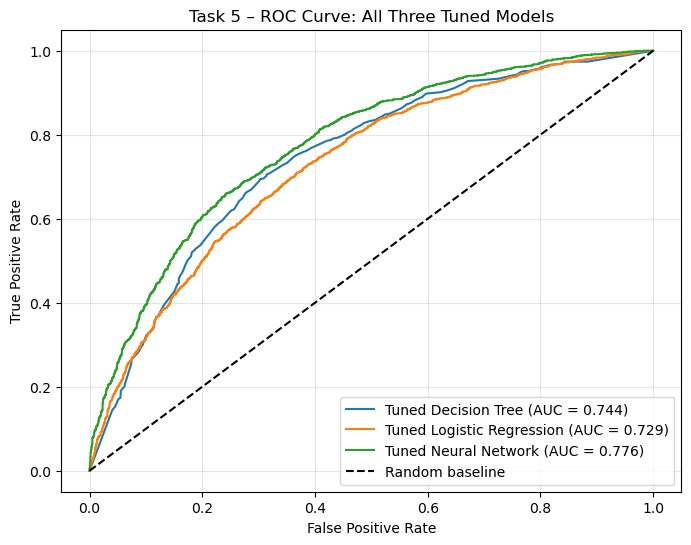

In [81]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

fpr_dt, tpr_dt, _ = roc_curve(y_test_ind, dt_test_prob)
fpr_lr, tpr_lr, _ = roc_curve(y_test_lr, lr_test_prob)
fpr_nn, tpr_nn, _ = roc_curve(y_test_nn, nn_test_prob)

auc_dt = roc_auc_score(y_test_ind, dt_test_prob)
auc_lr = roc_auc_score(y_test_lr, lr_test_prob)
auc_nn = roc_auc_score(y_test_nn, nn_test_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, label=f'Tuned Decision Tree (AUC = {auc_dt:.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'Tuned Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_nn, tpr_nn, label=f'Tuned Neural Network (AUC = {auc_nn:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Task 5 – ROC Curve: All Three Tuned Models')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [84]:
dt_precision = precision_score(y_test_ind, dt_test_pred)
dt_recall = recall_score(y_test_ind, dt_test_pred)
dt_f1 = f1_score(y_test_ind, dt_test_pred)
dt_gap = dt_train_accuracy - dt_test_accuracy

lr_precision = precision_score(y_test_lr, lr_test_pred)
lr_recall = recall_score(y_test_lr, lr_test_pred)
lr_f1 = f1_score(y_test_lr, lr_test_pred)
lr_gap = lr_train_acc - lr_test_acc

nn_precision = precision_score(y_test_nn, nn_test_pred)
nn_recall = recall_score(y_test_nn, nn_test_pred)
nn_f1 = f1_score(y_test_nn, nn_test_pred)
nn_gap = nn_train_acc - nn_test_acc

import pandas as pd
model_comparison = pd.DataFrame({
    'Model': ['Tuned Decision Tree', 'Tuned Logistic Regression', 'Tuned Neural Network'],
    'Train Accuracy': [round(dt_train_accuracy, 4), round(lr_train_acc, 4), round(nn_train_acc, 4)],
    'Test Accuracy': [round(dt_test_accuracy, 4), round(lr_test_acc, 4), round(nn_test_acc, 4)],
    'AUC': [round(auc_dt, 4), round(auc_lr, 4), round(auc_nn, 4)],
    'Precision': [round(dt_precision, 4), round(lr_precision, 4), round(nn_precision, 4)],
    'Recall': [round(dt_recall, 4), round(lr_recall, 4), round(nn_recall, 4)],
    'F1-score': [round(dt_f1, 4), round(lr_f1, 4), round(nn_f1, 4)],
    'Train-Test Accuracy Gap': [round(dt_gap, 4), round(lr_gap, 4), round(nn_gap, 4)]
})

model_comparison

,Model,Train Accuracy,Test Accuracy,AUC,Precision,Recall,F1-score,Train-Test Accuracy Gap
0,Tuned Decision Tree,0.7702,0.6981,0.7438,0.7176,0.7705,0.7431,0.0721
1,Tuned Logistic Regression,0.6869,0.6797,0.7292,0.6967,0.7701,0.7316,0.0072
2,Tuned Neural Network,0.8078,0.7099,0.7757,0.7296,0.7756,0.7519,0.0979
